# 🛠️ Preparación de los Datos


In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)
from imblearn.over_sampling import SMOTE
from collections import Counter

# Carga del dataset tratado (Parte 1)
df = pd.read_csv('TelecomX_tratado.csv')

print(" Archivo cargado correctamente")
print(f" Shape: {df.shape[0]} filas x {df.shape[1]} columnas")

print("\n Columnas y tipos de dato:")
print("="*50)
for i, col in enumerate(df.columns, 1):
    nulos = df[col].isnull().sum()
    alerta = "  Cuidado  " + str(nulos) + " nulos" if nulos > 0 else ""
    print(f"  {i:02d}. {col:<30} {str(df[col].dtype):<10}{alerta}")

print(f"\n Muestra del dataset:")
display(df.head())

 Archivo cargado correctamente
 Shape: 7043 filas x 22 columnas

 Columnas y tipos de dato:
  01. ID_Cliente                     object    
  02. Evasion                        int64     
  03. Genero                         object    
  04. Adulto_Mayor                   int64     
  05. Pareja                         int64     
  06. Dependientes                   int64     
  07. Meses_Contrato                 int64     
  08. Servicio_Telefono              int64     
  09. Lineas_Multiples               object    
  10. Servicio_Internet              object    
  11. Seguridad_Online               object    
  12. Respaldo_Online                object    
  13. Proteccion_Dispositivo         object    
  14. Soporte_Tecnico                object    
  15. Streaming_TV                   object    
  16. Streaming_Peliculas            object    
  17. Tipo_Contrato                  object    
  18. Factura_Digital                int64     
  19. Metodo_Pago                    object 

,ID_Cliente,Evasion,Genero,Adulto_Mayor,Pareja,Dependientes,Meses_Contrato,Servicio_Telefono,Lineas_Multiples,Servicio_Internet,...,Proteccion_Dispositivo,Soporte_Tecnico,Streaming_TV,Streaming_Peliculas,Tipo_Contrato,Factura_Digital,Metodo_Pago,Cargos_Mensuales,Cargos_Totales,Cuentas_Diarias
0,0002-orfbo,0,Femenino,0,1,1,9,1,no,DSL,...,no,yes,yes,no,Un año,1,Cheque por correo,65.6,593.30,2.19
1,0003-mknfe,0,Masculino,0,0,0,9,1,yes,DSL,...,no,no,no,yes,Mes a mes,0,Cheque por correo,59.9,542.40,2.00
2,0004-tlhlj,1,Masculino,0,0,0,4,1,no,Fibra óptica,...,yes,no,no,no,Mes a mes,1,Cheque electrónico,73.9,280.85,2.46
3,0011-igkff,1,Masculino,1,1,0,13,1,no,Fibra óptica,...,yes,no,yes,yes,Mes a mes,1,Cheque electrónico,98.0,1237.85,3.27
4,0013-exchz,1,Femenino,1,1,0,3,1,no,Fibra óptica,...,no,yes,yes,no,Mes a mes,1,Cheque por correo,83.9,267.40,2.80


In [23]:
# Eliminación de columnas irrelevantes
print(" COLUMNAS ANTES DE LA LIMPIEZA:")
print("_"*50)
print(f"  Total columnas: {df.shape[1]}")
for col in df.columns:
    print(f"  • {col}")

# ID_Cliente es un identificador único — no aporta valor predictivo
# y puede causar sobreajuste (overfitting) si se incluye en el modelo
cols_eliminar = ['ID_Cliente']

df = df.drop(columns=cols_eliminar)

print(f"\n  Columnas eliminadas: {cols_eliminar}")
print(f"\n COLUMNAS DESPUÉS DE LA LIMPIEZA:")
print("_"*50)
print(f"  Total columnas: {df.shape[1]}")
for col in df.columns:
    print(f"  • {col}")

print(f"\n Shape final: {df.shape[0]} filas x {df.shape[1]} columnas")

 COLUMNAS ANTES DE LA LIMPIEZA:
__________________________________________________
  Total columnas: 22
  • ID_Cliente
  • Evasion
  • Genero
  • Adulto_Mayor
  • Pareja
  • Dependientes
  • Meses_Contrato
  • Servicio_Telefono
  • Lineas_Multiples
  • Servicio_Internet
  • Seguridad_Online
  • Respaldo_Online
  • Proteccion_Dispositivo
  • Soporte_Tecnico
  • Streaming_TV
  • Streaming_Peliculas
  • Tipo_Contrato
  • Factura_Digital
  • Metodo_Pago
  • Cargos_Mensuales
  • Cargos_Totales
  • Cuentas_Diarias

  Columnas eliminadas: ['ID_Cliente']

 COLUMNAS DESPUÉS DE LA LIMPIEZA:
__________________________________________________
  Total columnas: 21
  • Evasion
  • Genero
  • Adulto_Mayor
  • Pareja
  • Dependientes
  • Meses_Contrato
  • Servicio_Telefono
  • Lineas_Multiples
  • Servicio_Internet
  • Seguridad_Online
  • Respaldo_Online
  • Proteccion_Dispositivo
  • Soporte_Tecnico
  • Streaming_TV
  • Streaming_Peliculas
  • Tipo_Contrato
  • Factura_Digital
  • Metodo_Pago
  • C

In [27]:
# Codificación de variables categóricas (OneHotEncoder - Scikit-learn)

print(" VARIABLES CATEGÓRICAS ANTES DEL ENCODING:")
print("_"*50)
cols_categoricas = df.select_dtypes(include='object').columns.tolist()
for col in cols_categoricas:
    print(f"  • {col:<30} {df[col].nunique()} categorías → {df[col].unique()}")

# OneHotEncoder — aprende las categorías y las aplica consistentemente
# drop='first'          → evita multicolinealidad
# handle_unknown='ignore' → maneja categorías nuevas sin romper el código
# sparse_output=False   → retorna array denso (compatible con pandas)
encoder = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')

encoded_array = encoder.fit_transform(df[cols_categoricas])
encoded_cols  = encoder.get_feature_names_out(cols_categoricas)

df_encoded = pd.DataFrame(encoded_array, columns=encoded_cols, index=df.index)
df = pd.concat([df.drop(columns=cols_categoricas), df_encoded], axis=1)
df[encoded_cols] = df[encoded_cols].astype(int)

print(f"\n ENCODING APLICADO CORRECTAMENTE")
print(f"\n NUEVAS COLUMNAS GENERADAS ({len(encoded_cols)}):")
print("_"*50)
for col in encoded_cols:
    print(f"  • {col}")

print(f"\n Shape final: {df.shape[0]} filas x {df.shape[1]} columnas")
print(f"   (de 21 columnas → {df.shape[1]} tras el encoding)")
print(f"\n Muestra del dataset codificado:")
display(df.head())

 VARIABLES CATEGÓRICAS ANTES DEL ENCODING:
__________________________________________________

 ENCODING APLICADO CORRECTAMENTE

 NUEVAS COLUMNAS GENERADAS (0):
__________________________________________________

 Shape final: 7043 filas x 32 columnas
   (de 21 columnas → 32 tras el encoding)

 Muestra del dataset codificado:


,Evasion,Adulto_Mayor,Pareja,Dependientes,Meses_Contrato,Servicio_Telefono,Factura_Digital,Cargos_Mensuales,Cargos_Totales,Cuentas_Diarias,...,Soporte_Tecnico_yes,Streaming_TV_no internet service,Streaming_TV_yes,Streaming_Peliculas_no internet service,Streaming_Peliculas_yes,Tipo_Contrato_Mes a mes,Tipo_Contrato_Un año,Metodo_Pago_Cheque por correo,Metodo_Pago_Tarjeta de crédito,Metodo_Pago_Transferencia bancaria
0,0,0,1,1,9,1,1,65.6,593.30,2.19,...,1,0,1,0,0,0,1,1,0,0
1,0,0,0,0,9,1,0,59.9,542.40,2.00,...,0,0,0,0,1,1,0,1,0,0
2,1,0,0,0,4,1,1,73.9,280.85,2.46,...,0,0,0,0,0,1,0,0,0,0
3,1,1,1,0,13,1,1,98.0,1237.85,3.27,...,0,0,1,0,1,1,0,0,0,0
4,1,1,1,0,3,1,1,83.9,267.40,2.80,...,1,0,1,0,0,1,0,1,0,0


 PROPORCIÓN DE CANCELACIÓN:


,Clientes,Porcentaje %
No cancelaron (0),5174,73.46
Cancelaron (1),1869,26.54



  Ratio de desbalance: 2.77:1
   Por cada cliente que cancela, hay 2.77 que permanecen

 Las clases están suficientemente balanceadas para el modelado.


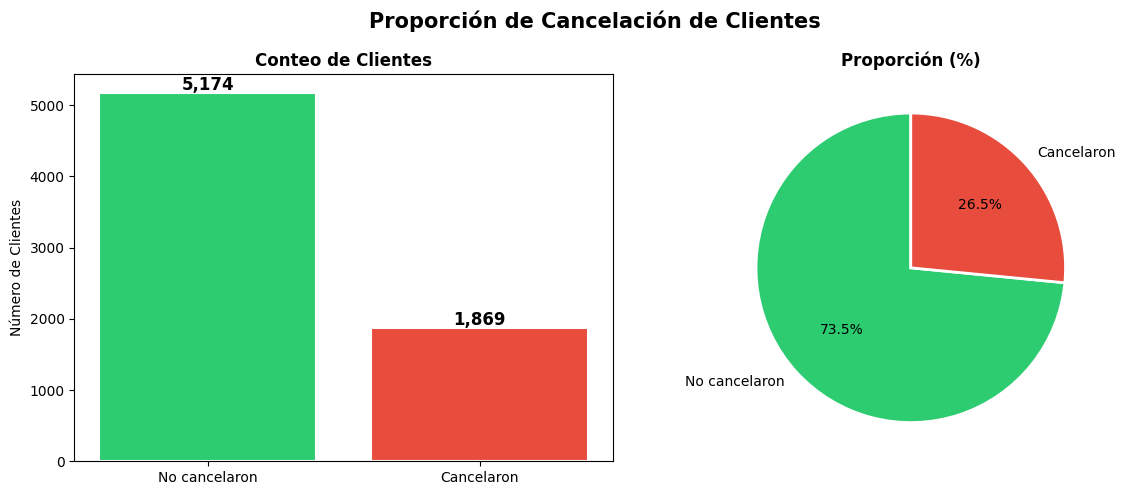

In [6]:
# Verificación de la proporción de cancelación (Balance de clases)

# Conteo y proporción
conteo     = df['Evasion'].value_counts()
proporcion = df['Evasion'].value_counts(normalize=True).mul(100).round(2)

# Tabla resumen
resumen = pd.DataFrame({
    'Clientes'    : conteo,
    'Porcentaje %': proporcion
})
resumen.index = ['No cancelaron (0)', 'Cancelaron (1)']

print(" PROPORCIÓN DE CANCELACIÓN:")
print("="*50)
display(resumen)

# Evaluación del desbalance
ratio = conteo[0] / conteo[1]
print(f"\n  Ratio de desbalance: {ratio:.2f}:1")
print(f"   Por cada cliente que cancela, hay {ratio:.2f} que permanecen")

if ratio > 3:
    print("\n  DESBALANCE SIGNIFICATIVO detectado.")
    print("   Considerar técnicas de balanceo antes del modelado:")
    print("   • Oversampling : SMOTE (genera muestras sintéticas de la clase minoritaria)")
    print("   • Undersampling: reducir la clase mayoritaria")
    print("   • class_weight='balanced' en los modelos de Scikit-learn")
else:
    print("\n Las clases están suficientemente balanceadas para el modelado.")

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Proporción de Cancelación de Clientes', fontsize=15, fontweight='bold')

COLORES = ['#2ecc71', '#e74c3c']

# Barras
barras = axes[0].bar(['No cancelaron', 'Cancelaron'], conteo.values,
                      color=COLORES, edgecolor='white', linewidth=1.5)
axes[0].set_title('Conteo de Clientes', fontweight='bold')
axes[0].set_ylabel('Número de Clientes')
for barra, val in zip(barras, conteo.values):
    axes[0].text(barra.get_x() + barra.get_width()/2,
                 barra.get_height() + 40,
                 f'{val:,}', ha='center', fontsize=12, fontweight='bold')

# Torta
axes[1].pie(proporcion.values,
            labels=['No cancelaron', 'Cancelaron'],
            autopct='%1.1f%%',
            colors=COLORES,
            startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proporción (%)', fontweight='bold')

plt.tight_layout()
plt.show()

 Nulos por columna:
Series([], dtype: int64)

 Nulos tratados con la mediana de Cargos_Totales
   Nulos restantes en el dataset: 0
 DISTRIBUCIÓN ANTES DEL BALANCEO:
__________________________________________________
  No cancelaron (0): 5,174
  Cancelaron    (1): 1,869
  Ratio: 2.77:1

 DISTRIBUCIÓN DESPUÉS DEL BALANCEO (SMOTE):
__________________________________________________
  No cancelaron (0): 5,174
  Cancelaron    (1): 5,174
  Ratio: 1.00:1

 Shape original  : (7043, 31)
 Shape balanceado: (10348, 31)


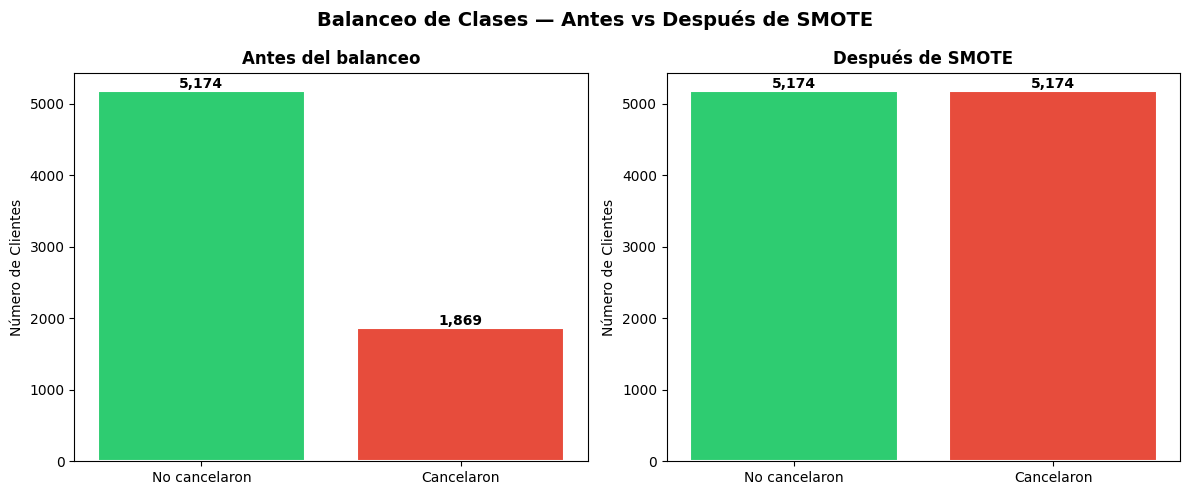

In [29]:
# Tratamiento de nulos antes del balanceo

print(" Nulos por columna:")
nulos = df.isnull().sum()
print(nulos[nulos > 0])

# Rellenar nulos de Cargos_Totales con la mediana
# Usamos mediana en vez de media porque es más robusta ante valores extremos
df['Cargos_Totales'] = df['Cargos_Totales'].fillna(df['Cargos_Totales'].median())

print(f"\n Nulos tratados con la mediana de Cargos_Totales")
print(f"   Nulos restantes en el dataset: {df.isnull().sum().sum()}")
# Separar features y target
X = df.drop(columns=['Evasion'])
y = df['Evasion']

print(" DISTRIBUCIÓN ANTES DEL BALANCEO:")
print("_"*50)
print(f"  No cancelaron (0): {Counter(y)[0]:,}")
print(f"  Cancelaron    (1): {Counter(y)[1]:,}")
print(f"  Ratio: {Counter(y)[0]/Counter(y)[1]:.2f}:1")

# Aplicar SMOTE
# SMOTE genera ejemplos sintéticos de la clase minoritaria (cancelaron)
# para igualar la proporción con la clase mayoritaria
smote = SMOTE(random_state=42)
X_balanced, y_balanced = smote.fit_resample(X, y)

print(f"\n DISTRIBUCIÓN DESPUÉS DEL BALANCEO (SMOTE):")
print("_"*50)
print(f"  No cancelaron (0): {Counter(y_balanced)[0]:,}")
print(f"  Cancelaron    (1): {Counter(y_balanced)[1]:,}")
print(f"  Ratio: {Counter(y_balanced)[0]/Counter(y_balanced)[1]:.2f}:1")
print(f"\n Shape original  : {X.shape}")
print(f" Shape balanceado: {X_balanced.shape}")

# Visualización comparativa
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Balanceo de Clases — Antes vs Después de SMOTE',
             fontsize=14, fontweight='bold')

COLORES = ['#2ecc71', '#e74c3c']
ETIQUETAS = ['No cancelaron', 'Cancelaron']

# Antes
axes[0].bar(ETIQUETAS, [Counter(y)[0], Counter(y)[1]],
            color=COLORES, edgecolor='white', linewidth=1.5)
axes[0].set_title('Antes del balanceo', fontweight='bold')
axes[0].set_ylabel('Número de Clientes')
for i, val in enumerate([Counter(y)[0], Counter(y)[1]]):
    axes[0].text(i, val + 40, f'{val:,}', ha='center', fontweight='bold')

# Después
axes[1].bar(ETIQUETAS, [Counter(y_balanced)[0], Counter(y_balanced)[1]],
            color=COLORES, edgecolor='white', linewidth=1.5)
axes[1].set_title('Después de SMOTE', fontweight='bold')
axes[1].set_ylabel('Número de Clientes')
for i, val in enumerate([Counter(y_balanced)[0], Counter(y_balanced)[1]]):
    axes[1].text(i, val + 40, f'{val:,}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [30]:
# 1. Separar features y target
X = X_balanced.copy()
y = y_balanced.copy()

# 2. División en entrenamiento y prueba (80/20)
# Importante: dividir ANTES de normalizar para evitar data leakage
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(" DIVISIÓN DEL DATASET:")
print("_"*50)
print(f"  Entrenamiento : {X_train.shape[0]:,} filas ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"  Prueba        : {X_test.shape[0]:,} filas ({X_test.shape[0]/len(X)*100:.0f}%)")

# 3. Identificar columnas numéricas a normalizar
# Solo normalizamos las numéricas continuas — las binarias (0/1) ya están en escala
cols_normalizar = ['Meses_Contrato', 'Cargos_Mensuales', 'Cargos_Totales', 'Cuentas_Diarias']

# 4. Aplicar StandardScaler
# fit() solo sobre entrenamiento — luego transform() sobre ambos
# Esto evita data leakage (que el modelo "vea" datos de prueba antes de tiempo)
scaler = StandardScaler()
X_train[cols_normalizar] = scaler.fit_transform(X_train[cols_normalizar])
X_test[cols_normalizar]  = scaler.transform(X_test[cols_normalizar])

print(f"\n NORMALIZACIÓN APLICADA (StandardScaler):")
print("_"*50)
print(f"  Columnas normalizadas: {cols_normalizar}")
print(f"\n Estadísticas tras normalización (set entrenamiento):")
display(X_train[cols_normalizar].describe().T.round(3))

print(f"\n Muestra del set de entrenamiento:")
display(X_train.head())

 DIVISIÓN DEL DATASET:
__________________________________________________
  Entrenamiento : 8,278 filas (80%)
  Prueba        : 2,070 filas (20%)

 NORMALIZACIÓN APLICADA (StandardScaler):
__________________________________________________
  Columnas normalizadas: ['Meses_Contrato', 'Cargos_Mensuales', 'Cargos_Totales', 'Cuentas_Diarias']

 Estadísticas tras normalización (set entrenamiento):


,count,mean,std,min,25%,50%,75%,max
Meses_Contrato,8278.0,0.0,1.0,-1.153,-0.944,-0.276,0.852,1.855
Cargos_Mensuales,8278.0,0.0,1.0,-1.740,-0.782,0.229,0.802,1.763
Cargos_Totales,8278.0,0.0,1.0,-0.930,-0.813,-0.397,0.555,3.032
Cuentas_Diarias,8278.0,-0.0,1.0,-1.743,-0.780,0.225,0.801,1.764



 Muestra del set de entrenamiento:


,Adulto_Mayor,Pareja,Dependientes,Meses_Contrato,Servicio_Telefono,Factura_Digital,Cargos_Mensuales,Cargos_Totales,Cuentas_Diarias,Genero_Masculino,...,Soporte_Tecnico_yes,Streaming_TV_no internet service,Streaming_TV_yes,Streaming_Peliculas_no internet service,Streaming_Peliculas_yes,Tipo_Contrato_Mes a mes,Tipo_Contrato_Un año,Metodo_Pago_Cheque por correo,Metodo_Pago_Tarjeta de crédito,Metodo_Pago_Transferencia bancaria
9772,0,0,0,0.100268,0,1,-0.003501,-0.033367,-0.002233,0,...,0,0,0,0,0,1,0,0,0,0
6152,0,1,1,0.142057,1,1,0.799557,0.431013,0.801199,0,...,0,0,0,0,1,1,0,0,0,0
2479,0,1,0,0.810684,1,0,-1.443020,-0.366482,-1.439408,0,...,0,1,0,1,0,0,1,0,0,0
3442,0,0,0,-0.568359,1,0,-1.697819,-0.800953,-1.701161,1,...,0,1,0,1,0,1,0,0,1,0
10123,0,0,0,-1.111619,1,1,-1.676009,-0.929027,-1.675013,0,...,0,1,0,1,0,1,0,1,0,0


# 🎯 Correlación y Selección de Variables

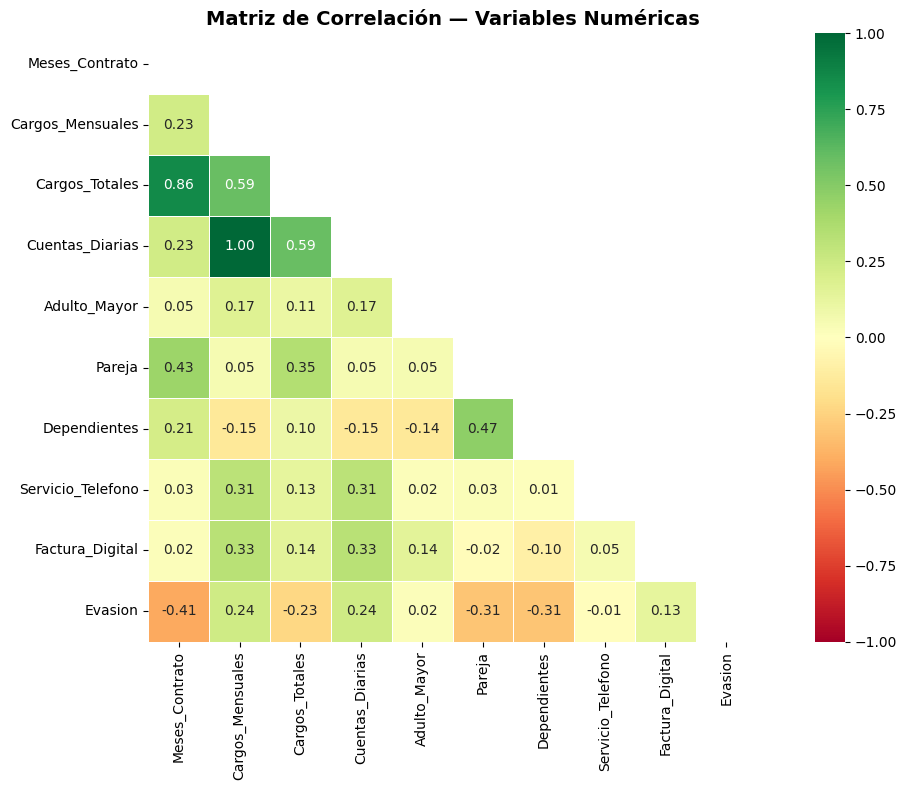

 CORRELACIÓN CON LA VARIABLE OBJETIVO (Evasion):
  Meses_Contrato            -0.413  🟢 protección          ████████
  Pareja                    -0.309  🟢 protección          ██████
  Dependientes              -0.307  🟢 protección          ██████
  Cuentas_Diarias            0.236  🔴 riesgo              ████
  Cargos_Mensuales           0.236  🔴 riesgo              ████
  Cargos_Totales            -0.231  🟢 protección          ████
  Factura_Digital            0.127  🔴 riesgo              ██
  Adulto_Mayor               0.021  🔴 riesgo              
  Servicio_Telefono         -0.012  🟢 protección          


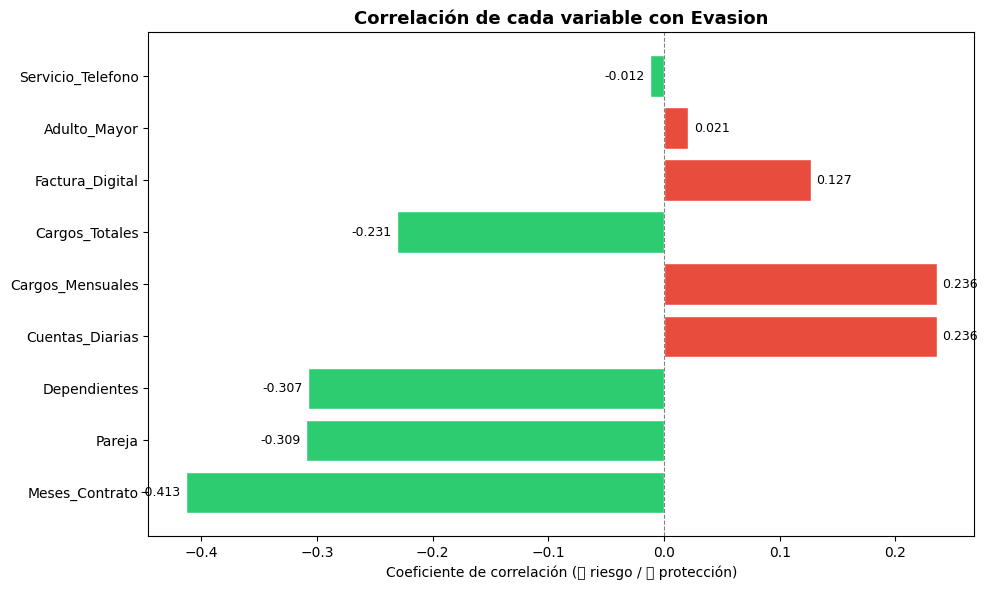

In [31]:
#  Análisis de Correlación

# Usamos el dataset balanceado completo (antes del split) para el análisis
cols_corr = ['Meses_Contrato', 'Cargos_Mensuales', 'Cargos_Totales',
             'Cuentas_Diarias', 'Adulto_Mayor', 'Pareja', 'Dependientes',
             'Servicio_Telefono', 'Factura_Digital', 'Evasion']

corr_matrix = X_balanced[cols_corr[:-1]].assign(Evasion=y_balanced).corr()

# 1. Heatmap completo
plt.figure(figsize=(12, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    linewidths=0.5,
    linecolor='white',
    square=True,
    vmin=-1, vmax=1
)
plt.title('Matriz de Correlación — Variables Numéricas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ── 2. Correlación específica con Evasion (ranking) ──────────────────────────
corr_target = corr_matrix['Evasion'].drop('Evasion').sort_values(key=abs, ascending=False)

print(" CORRELACIÓN CON LA VARIABLE OBJETIVO (Evasion):")
print("="*60)
for var, val in corr_target.items():
    # Positivo = mayor valor → más riesgo de cancelar (🔴)
    # Negativo = mayor valor → menor riesgo de cancelar (🟢)
    direccion = '🔴 riesgo' if val > 0 else '🟢 protección'
    barra = '█' * int(abs(val) * 20)
    print(f"  {var:<25} {val:>6.3f}  {direccion:<20}  {barra}")

# ── 3. Visualización del ranking ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
colores = ['#e74c3c' if v > 0 else '#2ecc71' for v in corr_target.values]
bars = ax.barh(corr_target.index, corr_target.values, color=colores, edgecolor='white')
ax.axvline(x=0, color='gray', linewidth=0.8, linestyle='--')
ax.set_title('Correlación de cada variable con Evasion', fontsize=13, fontweight='bold')
ax.set_xlabel('Coeficiente de correlación (🔴 riesgo / 🟢 protección)')
for bar, val in zip(bars, corr_target.values):
    ax.text(val + (0.005 if val >= 0 else -0.005),
            bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center',
            ha='left' if val >= 0 else 'right', fontsize=9)
plt.tight_layout()
plt.show()

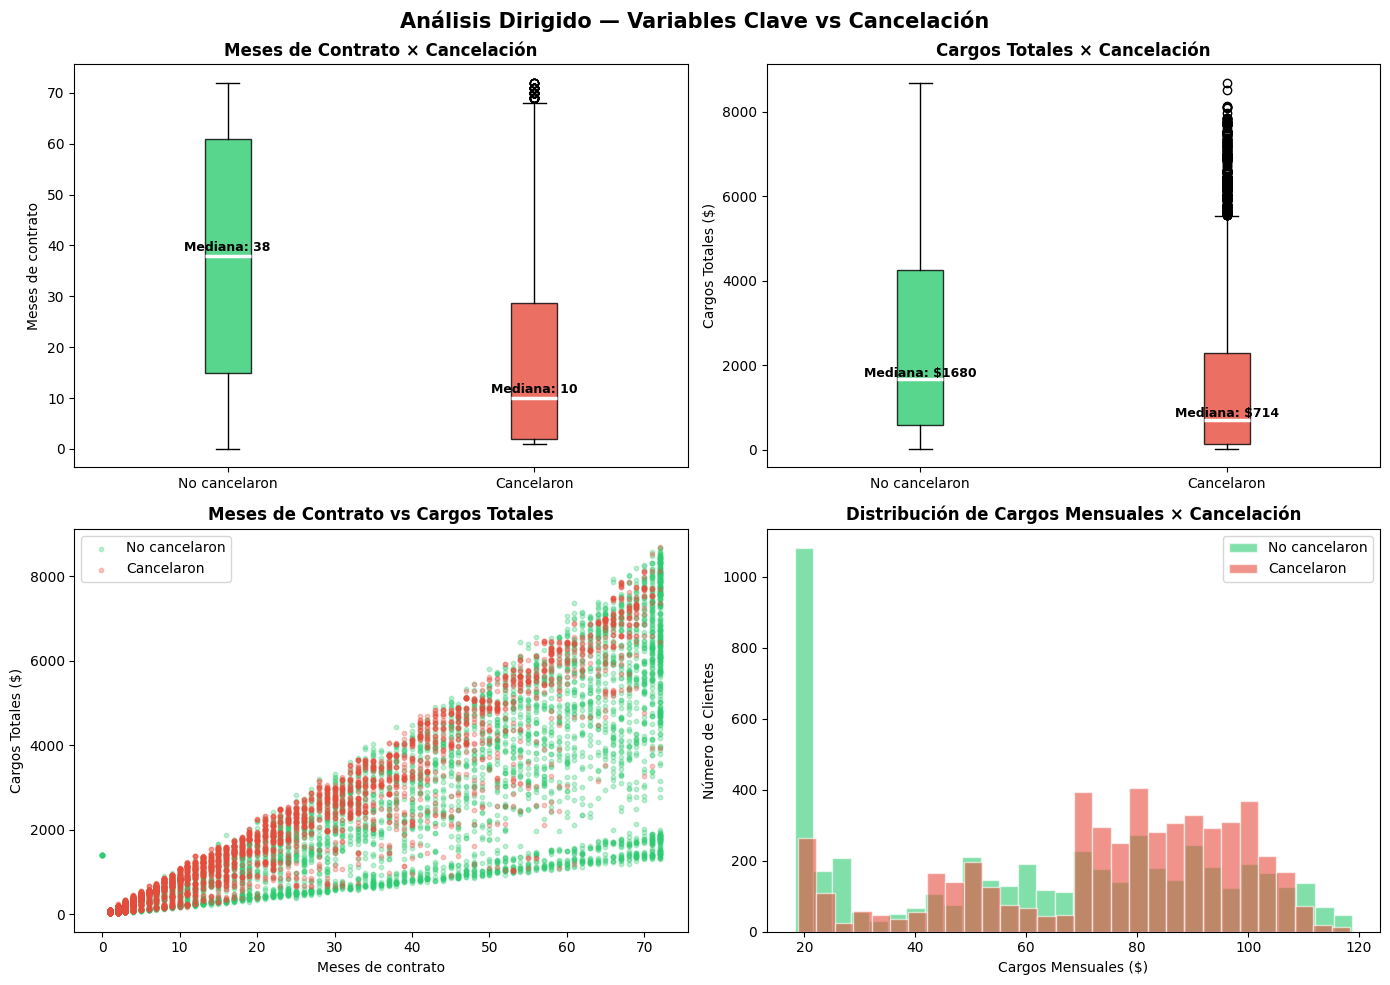


 ESTADÍSTICAS COMPARATIVAS — VARIABLES CLAVE:
_________________________________________________________________

  * Meses_Contrato:


,mean,median,std
No cancelaron,37.57,38.0,24.11
Cancelaron,17.74,10.0,19.31



  * Cargos_Totales:


,mean,median,std
No cancelaron,2552.88,1679.52,2327.59
Cancelaron,1543.74,714.17,1905.89



  * Cargos_Mensuales:


,mean,median,std
No cancelaron,61.27,64.43,31.09
Cancelaron,74.79,79.95,24.32


In [33]:
# Análisis Dirigido: Variables clave vs Evasión

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Análisis Dirigido — Variables Clave vs Cancelación',
             fontsize=15, fontweight='bold')

COLORES   = ['#2ecc71', '#e74c3c']
ETIQUETAS = ['No cancelaron', 'Cancelaron']

# Datos sin balanceo para reflejar la realidad del negocio
df_analisis = X.copy()
df_analisis['Evasion'] = y.values

# 1. Boxplot: Meses_Contrato vs Evasión
data_meses = [df_analisis[df_analisis['Evasion'] == 0]['Meses_Contrato'],
              df_analisis[df_analisis['Evasion'] == 1]['Meses_Contrato']]
bp1 = axes[0, 0].boxplot(data_meses, tick_labels=ETIQUETAS, patch_artist=True,
                          medianprops=dict(color='white', linewidth=2.5))
for patch, color in zip(bp1['boxes'], COLORES):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
axes[0, 0].set_title('Meses de Contrato × Cancelación', fontweight='bold')
axes[0, 0].set_ylabel('Meses de contrato')
for i, datos in enumerate(data_meses):
    axes[0, 0].text(i + 1, datos.median() + 1, f'Mediana: {datos.median():.0f}',
                    ha='center', fontsize=9, fontweight='bold', color='black')

# 2. Boxplot: Cargos_Totales vs Evasión
data_cargos = [df_analisis[df_analisis['Evasion'] == 0]['Cargos_Totales'],
               df_analisis[df_analisis['Evasion'] == 1]['Cargos_Totales']]
bp2 = axes[0, 1].boxplot(data_cargos, tick_labels=ETIQUETAS, patch_artist=True,
                          medianprops=dict(color='white', linewidth=2.5))
for patch, color in zip(bp2['boxes'], COLORES):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
axes[0, 1].set_title('Cargos Totales × Cancelación', fontweight='bold')
axes[0, 1].set_ylabel('Cargos Totales ($)')
for i, datos in enumerate(data_cargos):
    axes[0, 1].text(i + 1, datos.median() + 50, f'Mediana: ${datos.median():.0f}',
                    ha='center', fontsize=9, fontweight='bold', color='black')

# 3. Scatter: Meses_Contrato vs Cargos_Totales coloreado por Evasión
for val, color, etiqueta in zip([0, 1], COLORES, ETIQUETAS):
    subset = df_analisis[df_analisis['Evasion'] == val]
    axes[1, 0].scatter(subset['Meses_Contrato'], subset['Cargos_Totales'],
                       c=color, label=etiqueta, alpha=0.3, s=10)
axes[1, 0].set_title('Meses de Contrato vs Cargos Totales', fontweight='bold')
axes[1, 0].set_xlabel('Meses de contrato')
axes[1, 0].set_ylabel('Cargos Totales ($)')
axes[1, 0].legend()

# 4. Histograma: Cargos_Mensuales vs Evasión
for val, color, etiqueta in zip([0, 1], COLORES, ETIQUETAS):
    subset = df_analisis[df_analisis['Evasion'] == val]
    axes[1, 1].hist(subset['Cargos_Mensuales'], bins=30, alpha=0.6,
                    color=color, label=etiqueta, edgecolor='white')
axes[1, 1].set_title('Distribución de Cargos Mensuales × Cancelación', fontweight='bold')
axes[1, 1].set_xlabel('Cargos Mensuales ($)')
axes[1, 1].set_ylabel('Número de Clientes')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

# ── Tabla de estadísticas comparativas ───────────────────────────────────────
print("\n ESTADÍSTICAS COMPARATIVAS — VARIABLES CLAVE:")
print("_"*65)
for col in ['Meses_Contrato', 'Cargos_Totales', 'Cargos_Mensuales']:
    stats = df_analisis.groupby('Evasion')[col].agg(['mean', 'median', 'std']).round(2)
    stats.index = ['No cancelaron', 'Cancelaron']
    print(f"\n  * {col}:")
    display(stats)

# 🤖 Modelado Predictivo

In [34]:
# Separación de datos: Entrenamiento y Prueba

# División ya realizada en la etapa de normalización (80/20)
# Se usó stratify=y para mantener la proporción de clases en ambos conjuntos

print(" DIVISIÓN DEL DATASET:")
print("_"*55)
print(f"  Total de muestras  : {len(X_train) + len(X_test):,}")
print(f"  Entrenamiento (80%): {len(X_train):,} filas")
print(f"  Prueba        (20%): {len(X_test):,} filas")

print(f"\n DISTRIBUCIÓN DE CLASES POR CONJUNTO:")
print("_"*55)

# Entrenamiento
train_dist = y_train.value_counts(normalize=True).mul(100).round(2)
print(f"\n  Entrenamiento:")
print(f"    No cancelaron (0): {train_dist[0]}%")
print(f"    Cancelaron    (1): {train_dist[1]}%")

# Prueba
test_dist = y_test.value_counts(normalize=True).mul(100).round(2)
print(f"\n  Prueba:")
print(f"    No cancelaron (0): {test_dist[0]}%")
print(f"    Cancelaron    (1): {test_dist[1]}%")

print(f"\n Se usó stratify=y para garantizar que ambos conjuntos")
print(f"   tengan la misma proporción de clases que el dataset original.")

 DIVISIÓN DEL DATASET:
_______________________________________________________
  Total de muestras  : 10,348
  Entrenamiento (80%): 8,278 filas
  Prueba        (20%): 2,070 filas

 DISTRIBUCIÓN DE CLASES POR CONJUNTO:
_______________________________________________________

  Entrenamiento:
    No cancelaron (0): 50.0%
    Cancelaron    (1): 50.0%

  Prueba:
    No cancelaron (0): 50.0%
    Cancelaron    (1): 50.0%

 Se usó stratify=y para garantizar que ambos conjuntos
   tengan la misma proporción de clases que el dataset original.


In [35]:
# Modelo 1: Regresión Logística
# Requiere normalización (ya aplicada en la etapa anterior)
# class_weight='balanced' da más peso a la clase minoritaria
modelo_lr = LogisticRegression(
    random_state=42,
    max_iter=1000,
    class_weight='balanced'
)
modelo_lr.fit(X_train, y_train)
print(" Modelo 1 — Regresión Logística entrenado correctamente")

# Modelo 2: Random Forest
# No requiere normalización — trabaja con reglas de división, no distancias
# n_estimators=100 → construye 100 árboles de decisión
modelo_rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)
modelo_rf.fit(X_train, y_train)
print(" Modelo 2 — Random Forest entrenado correctamente")

# Resumen de configuración
print(f"\n CONFIGURACIÓN DE LOS MODELOS:")
print("_"*55)
print(f"\n  Modelo 1 — Regresión Logística:")
print(f"    • Normalización    : Sí (StandardScaler aplicado)")
print(f"    • max_iter         : 1000")
print(f"    • class_weight     : balanced")
print(f"    • Ventaja          : Interpretable, coeficientes claros")

print(f"\n  Modelo 2 — Random Forest:")
print(f"    • Normalización    : No necesaria")
print(f"    • n_estimators     : 100 árboles")
print(f"    • class_weight     : balanced")
print(f"    • Ventaja          : Captura relaciones no lineales,")
print(f"                         entrega importancia de variables")

print(f"\n Datos de entrenamiento usados: {X_train.shape[0]:,} filas x {X_train.shape[1]} columnas")

 Modelo 1 — Regresión Logística entrenado correctamente
 Modelo 2 — Random Forest entrenado correctamente

 CONFIGURACIÓN DE LOS MODELOS:
_______________________________________________________

  Modelo 1 — Regresión Logística:
    • Normalización    : Sí (StandardScaler aplicado)
    • max_iter         : 1000
    • class_weight     : balanced
    • Ventaja          : Interpretable, coeficientes claros

  Modelo 2 — Random Forest:
    • Normalización    : No necesaria
    • n_estimators     : 100 árboles
    • class_weight     : balanced
    • Ventaja          : Captura relaciones no lineales,
                         entrega importancia de variables

 Datos de entrenamiento usados: 8,278 filas x 31 columnas


  MODELO: Regresión Logística
_______________________________________________________
  Exactitud  (train) : 0.8363
  Exactitud  (test)  : 0.8232
  Diferencia         : 0.0131 Like, Sin overfitting significativo

  Precisión          : 0.8207
  Recall             : 0.8271
  F1-Score           : 0.8239

  Reporte detallado:
               precision    recall  f1-score   support

No cancelaron       0.83      0.82      0.82      1035
   Cancelaron       0.82      0.83      0.82      1035

     accuracy                           0.82      2070
    macro avg       0.82      0.82      0.82      2070
 weighted avg       0.82      0.82      0.82      2070

  MODELO: Random Forest
_______________________________________________________
  Exactitud  (train) : 0.9987
  Exactitud  (test)  : 0.8420
  Diferencia         : 0.1566  Cuidado, Posible overfitting

  Precisión          : 0.8327
  Recall             : 0.8560
  F1-Score           : 0.8442

  Reporte detallado:
               precision    r

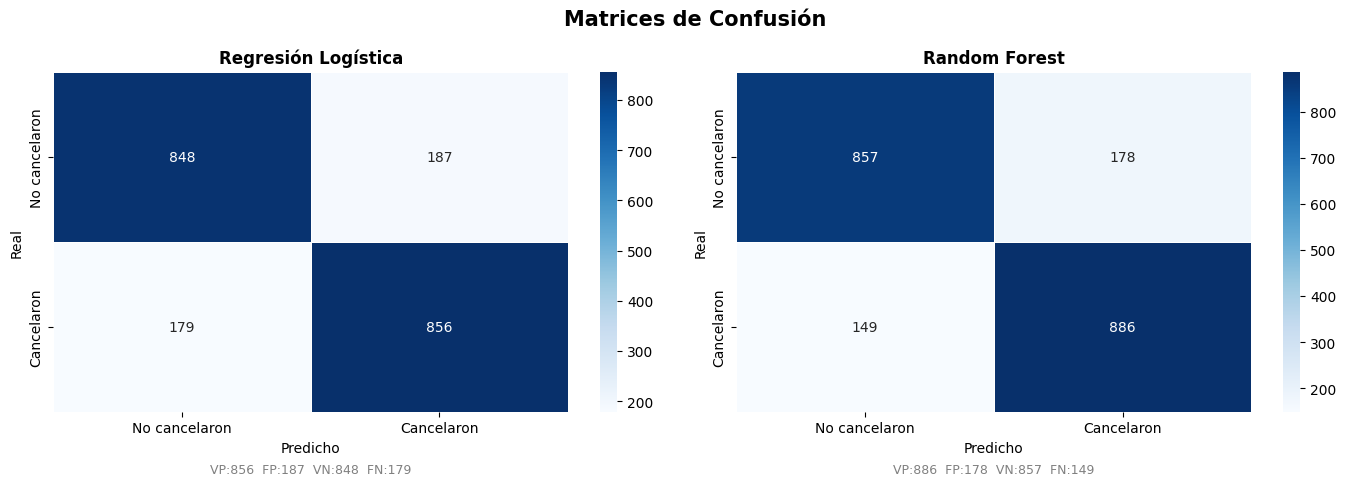


 TABLA COMPARATIVA DE MODELOS:
_______________________________________________________


,Exactitud (train),Exactitud (test),Precisión,Recall,F1-Score
Regresión Logística,0.8363,0.8232,0.8207,0.8271,0.8239
Random Forest,0.9987,0.8420,0.8327,0.8560,0.8442



 ANÁLISIS CRÍTICO:
_______________________________________________________

  Regresión Logística:
 Excelente, Buen balance entre entrenamiento y prueba (diff: 0.0131)

  Random Forest:
  Cuidado, Overfitting detectado (diferencia train/test: 0.1566)
     → Solución: reducir max_depth o ajustar max_features

 Mejor modelo por F1-Score: Random Forest
   F1-Score : 0.8442
   Recall   : 0.8560


In [37]:
#  Evaluación de Modelos

modelos = {
    'Regresión Logística': modelo_lr,
    'Random Forest'      : modelo_rf
}

resultados = {}

for nombre, modelo in modelos.items():
    #  Predicciones
    y_pred       = modelo.predict(X_test)
    y_pred_train = modelo.predict(X_train)

    # Métricas
    acc       = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall    = recall_score(y_test, y_pred)
    f1        = f1_score(y_test, y_pred)
    acc_train = accuracy_score(y_train, y_pred_train)

    resultados[nombre] = {
        'Exactitud (train)': acc_train,
        'Exactitud (test)' : acc,
        'Precisión'        : precision,
        'Recall'           : recall,
        'F1-Score'         : f1
    }


    print(f"  MODELO: {nombre}")
    print(f"{'_'*55}")
    print(f"  Exactitud  (train) : {acc_train:.4f}")
    print(f"  Exactitud  (test)  : {acc:.4f}")
    diff = abs(acc_train - acc)
    print(f"  Diferencia         : {diff:.4f}", end="")
    print("  Cuidado, Posible overfitting" if diff > 0.05 else " Like, Sin overfitting significativo")
    print(f"\n  Precisión          : {precision:.4f}")
    print(f"  Recall             : {recall:.4f}")
    print(f"  F1-Score           : {f1:.4f}")
    print(f"\n  Reporte detallado:")
    print(classification_report(y_test, y_pred,
          target_names=['No cancelaron', 'Cancelaron']))

# Matrices de confusión
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Matrices de Confusión', fontsize=15, fontweight='bold')

for ax, (nombre, modelo) in zip(axes, modelos.items()):
    y_pred = modelo.predict(X_test)
    cm     = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No cancelaron', 'Cancelaron'],
                yticklabels=['No cancelaron', 'Cancelaron'],
                linewidths=0.5, linecolor='white')
    ax.set_title(nombre, fontweight='bold')
    ax.set_ylabel('Real')
    ax.set_xlabel('Predicho')
    vp = cm[1,1]; fp = cm[0,1]; fn = cm[1,0]; vn = cm[0,0]
    ax.text(0.5, -0.18, f'VP:{vp}  FP:{fp}  VN:{vn}  FN:{fn}',
            ha='center', transform=ax.transAxes, fontsize=9, color='gray')

plt.tight_layout()
plt.show()

# Tabla comparativa
print("\n TABLA COMPARATIVA DE MODELOS:")
print("_"*55)
df_resultados = pd.DataFrame(resultados).T
df_resultados = df_resultados.map(lambda x: f"{x:.4f}")
display(df_resultados)

# Análisis crítico
print("\n ANÁLISIS CRÍTICO:")
print("_"*55)

for nombre, res in resultados.items():
    diff = abs(res['Exactitud (train)'] - res['Exactitud (test)'])
    print(f"\n  {nombre}:")
    if diff > 0.05:
        print(f"  Cuidado, Overfitting detectado (diferencia train/test: {diff:.4f})")
        print(f"     → Solución: reducir max_depth o ajustar max_features")
    elif res['Exactitud (test)'] < 0.70:
        print(f"  Cuidado, Underfitting detectado (exactitud test: {res['Exactitud (test)']:.4f})")
        print(f"     → Solución: aumentar la complejidad del modelo")
    else:
        print(f" Excelente, Buen balance entre entrenamiento y prueba (diff: {diff:.4f})")

mejor = max(resultados, key=lambda x: resultados[x]['F1-Score'])
print(f"\n Mejor modelo por F1-Score: {mejor}")
print(f"   F1-Score : {resultados[mejor]['F1-Score']:.4f}")
print(f"   Recall   : {resultados[mejor]['Recall']:.4f}")

# 📋 Interpretación y Conclusiones

## Resumen del Pipeline de Machine Learning

El siguiente pipeline fue construido para predecir la cancelación de clientes de TelecomX LATAM:

| Etapa | Detalle |
|---|---|
| Dataset | 7,043 registros × 22 columnas (Parte 1) |
| Limpieza | Eliminación de ID_Cliente, imputación de 11 nulos en Cargos_Totales con la mediana |
| Encoding | OneHotEncoder (Scikit-learn) → 32 columnas finales |
| Balanceo | SMOTE → 10,348 registros balanceados (50%/50%) |
| Split | 80% entrenamiento (8,278) / 20% prueba (2,070) |
| Normalización | StandardScaler sobre variables numéricas continuas |
| Modelos | Regresión Logística + Random Forest |

---

## Rendimiento de los Modelos

| Métrica | Regresión Logística | Random Forest |
|---|---|---|
| Exactitud (train) | 83.63% | **99.87%** |
| Exactitud (test) | 82.32% | **84.20%** |
| Precisión | 82.07% | **83.27%** |
| Recall | 82.71% | **85.60%** |
| F1-Score | 82.39% | **84.42%** |
| Overfitting | Bien, No (diff: 1.31%) | Cuidado, Sí (diff: 15.66%) |

**¿Cuál modelo tuvo mejor desempeño?**
Random Forest obtuvo el mejor F1-Score (84.42%) y el mejor Recall (85.60%), lo que significa que detecta correctamente al **85.6% de los clientes que realmente van a cancelar** — exactamente lo que necesita TelecomX.

**¿Hubo overfitting?**
- **Regresión Logística:** Sin overfitting. Solo 1.31% de diferencia entre train y test — el modelo generaliza muy bien a datos nuevos.
- **Random Forest:** Overfitting detectado. 99.87% en entrenamiento vs 84.20% en prueba (diferencia de 15.66%). El modelo memorizó demasiado los datos de entrenamiento. Para reducirlo se puede limitar la profundidad máxima de los árboles (`max_depth`) o reducir el número de features por árbol (`max_features`).

---

## Factores más Influyentes en la Cancelación

Ambos modelos, con enfoques completamente distintos, coincidieron en **5 variables clave**:

| Variable | Reg. Logística | Random Forest | Impacto |
|---|---|---|---|
| **Meses_Contrato** | -1.821 (protección) | 0.131 (1° más importante) | A mayor antigüedad, menor riesgo de cancelar |
| **Cargos_Mensuales** | +3.063 (riesgo) | 0.105 (3° más importante) | Mayor factura mensual aumenta el riesgo |
| **Cuentas_Diarias** | +3.093 (riesgo) | 0.095 (4° más importante) | Derivada de Cargos_Mensuales, confirma el patrón |
| **Seguridad_Online** | -1.777 (protección) | 0.044 (7° más importante) | Tener seguridad online reduce la evasión |
| **Soporte_Tecnico** | -1.914 (protección) | 0.050 (6° más importante) | El soporte técnico actúa como ancla de permanencia |

### Hallazgos adicionales por modelo:

**Regresión Logística destacó además:**
- `Servicio_Internet_Fibra óptica` (-4.77) → actúa como protección en este modelo
- `Streaming_Peliculas_yes` (-2.18) y `Streaming_TV_yes` (-2.04) → los servicios adicionales retienen clientes

**Random Forest destacó además:**
- `Tipo_Contrato_Mes a mes` (0.060) → contratos cortos son el segundo factor de riesgo más importante
- `Pareja` (0.029) y `Dependientes` (0.027) → los vínculos familiares protegen contra la cancelación

---

## Perfil del Cliente con Mayor Riesgo de Cancelación

Combinando los hallazgos de ambos modelos, el cliente con mayor probabilidad de cancelar tiene:

- **Pocos meses de contrato** (menos de 12 meses)
- **Cargos mensuales altos** (superiores a $70)
- **Contrato mes a mes** (sin compromiso de permanencia)
- **Sin soporte técnico** contratado
- **Sin seguridad online** contratada
- **Sin pareja ni dependientes** (menor costo de salida)

---

## Estrategias de Retención Recomendadas

** 1. Intervención temprana en los primeros 12 meses**
`Meses_Contrato` es el predictor más poderoso según Random Forest. Diseñar un programa de onboarding activo con beneficios escalonados a los 3, 6 y 12 meses reduce el riesgo en la ventana más crítica.

** 2. Migración de contratos mensuales a anuales**
`Tipo_Contrato_Mes a mes` es el segundo factor de riesgo en Random Forest. Ofrecer descuentos del 15-20% para migrar a contratos anuales o bianuales elimina la principal barrera de salida.

** 3. Revisión de la estructura de precios**
`Cargos_Mensuales` y `Cuentas_Diarias` aparecen como factores de riesgo en ambos modelos. Evaluar si los clientes con facturación alta perciben el valor correspondiente y considerar planes intermedios más accesibles.

** 4. Bundling de servicios adicionales**
`Soporte_Tecnico` y `Seguridad_Online` son factores de **protección** en ambos modelos. Incluirlos en paquetes base o ofrecerlos gratis durante los primeros meses aumenta significativamente la retención.

** 5. Planes orientados a clientes individuales**
`Pareja` y `Dependientes` son factores protectores. Los clientes sin vínculos familiares tienen menor costo de salida — diseñar beneficios específicos para este segmento reduce su riesgo de cancelación.

** 6. Implementar el modelo predictivo en producción**
Con un F1-Score de 84.42% y un Recall de 85.60%, el modelo Random Forest puede identificar en tiempo real a los clientes con mayor probabilidad de cancelar, permitiendo activar campañas de retención **antes** de que la cancelación ocurra.

---

> **Conclusión final:** TelecomX LATAM tiene en sus manos una herramienta predictiva capaz de anticiparse al churn con un 84% de precisión. Los factores más críticos — antigüedad, tipo de contrato, cargos mensuales y servicios adicionales — son todos accionables mediante estrategias comerciales concretas. El siguiente paso natural es implementar este modelo en un pipeline productivo que evalúe el riesgo de cada cliente de forma continua y automatizada.



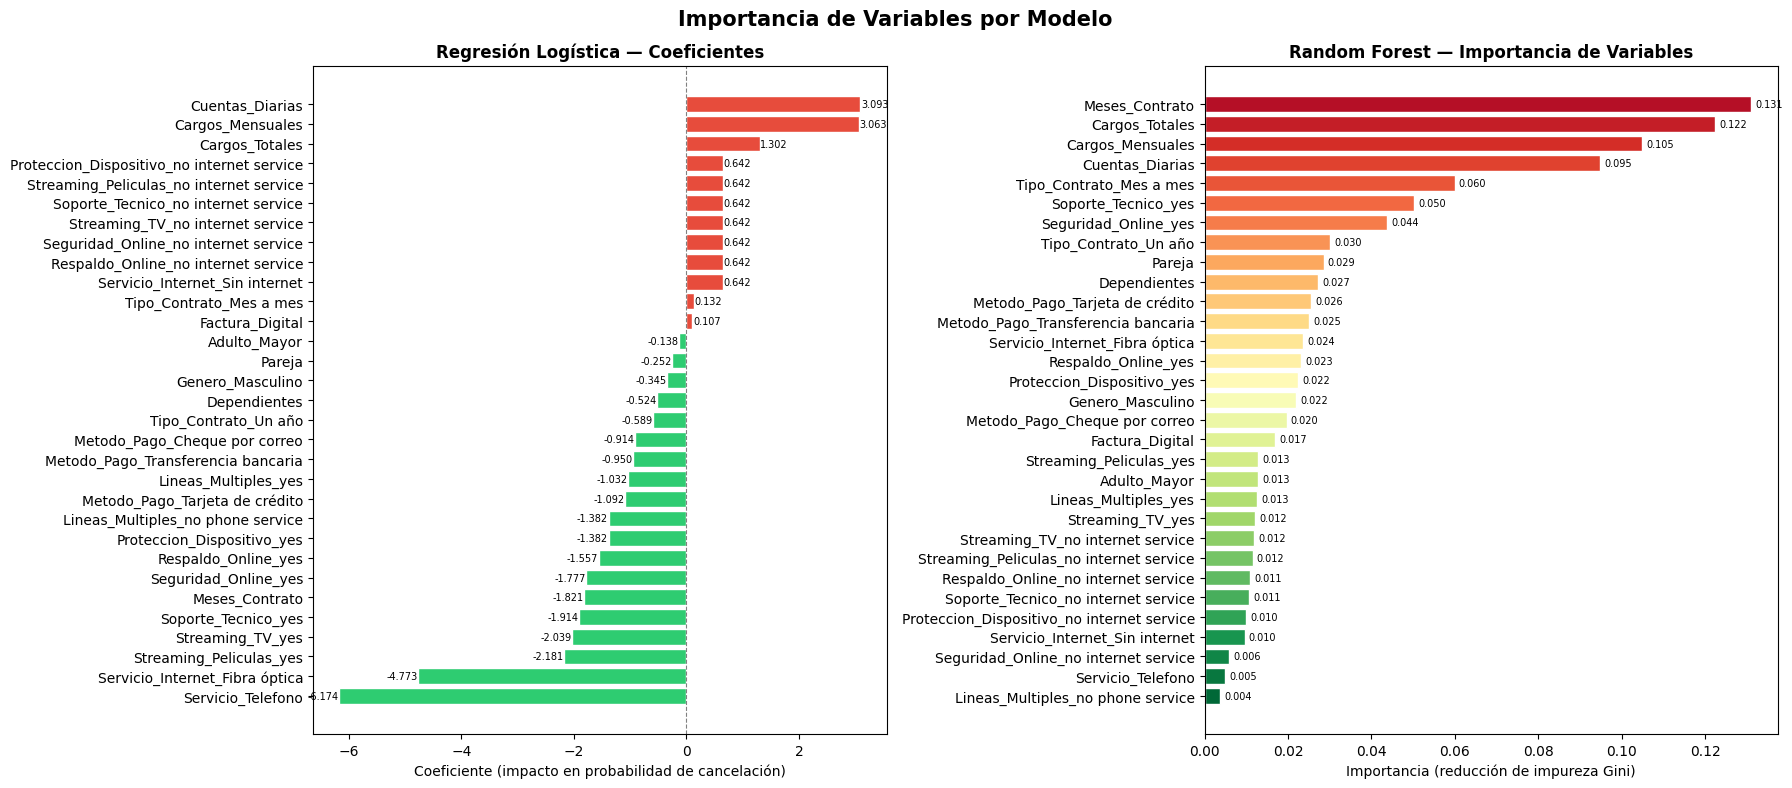

 TOP 10 VARIABLES MÁS RELEVANTES:
_________________________________________________________________

  Regresión Logística (por coeficiente absoluto):
  01. Servicio_Telefono                        -6.1741  🟢 protección
  02. Servicio_Internet_Fibra óptica           -4.7729  🟢 protección
  03. Cuentas_Diarias                           3.0929  🔴 riesgo
  04. Cargos_Mensuales                          3.0632  🔴 riesgo
  05. Streaming_Peliculas_yes                  -2.1813  🟢 protección
  06. Streaming_TV_yes                         -2.0391  🟢 protección
  07. Soporte_Tecnico_yes                      -1.9135  🟢 protección
  08. Meses_Contrato                           -1.8213  🟢 protección
  09. Seguridad_Online_yes                     -1.7766  🟢 protección
  10. Respaldo_Online_yes                      -1.5570  🟢 protección

  Random Forest (por importancia Gini):
  01. Meses_Contrato                            0.1309  ██████████████████████████
  02. Cargos_Totales                       

In [38]:
# Importancia de Variables

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle('Importancia de Variables por Modelo', fontsize=15, fontweight='bold')

# Modelo 1: Regresión Logística — Coeficientes
# Los coeficientes indican cuánto contribuye cada variable a la probabilidad
# de cancelación. Positivo = aumenta el riesgo, Negativo = lo reduce.

coeficientes = pd.Series(modelo_lr.coef_[0], index=X_train.columns)
coeficientes = coeficientes.sort_values(ascending=True)

colores_lr = ['#e74c3c' if v > 0 else '#2ecc71' for v in coeficientes.values]
axes[0].barh(coeficientes.index, coeficientes.values,
             color=colores_lr, edgecolor='white')
axes[0].axvline(x=0, color='gray', linewidth=0.8, linestyle='--')
axes[0].set_title('Regresión Logística — Coeficientes', fontweight='bold')
axes[0].set_xlabel('Coeficiente (impacto en probabilidad de cancelación)')
for i, (idx, val) in enumerate(coeficientes.items()):
    axes[0].text(val + (0.01 if val >= 0 else -0.01), i,
                 f'{val:.3f}', va='center',
                 ha='left' if val >= 0 else 'right', fontsize=7)

# Modelo 2: Random Forest — Feature Importance
# Mide cuánto contribuye cada variable a reducir la impureza (Gini)
# en los árboles. Siempre positivo, mayor = más importante.

importancias = pd.Series(modelo_rf.feature_importances_, index=X_train.columns)
importancias = importancias.sort_values(ascending=True)

colores_rf = plt.cm.RdYlGn_r(
    [i / len(importancias) for i in range(len(importancias))]
)
axes[1].barh(importancias.index, importancias.values,
             color=colores_rf, edgecolor='white')
axes[1].set_title('Random Forest — Importancia de Variables', fontweight='bold')
axes[1].set_xlabel('Importancia (reducción de impureza Gini)')
for i, (idx, val) in enumerate(importancias.items()):
    axes[1].text(val + 0.001, i, f'{val:.3f}', va='center',
                 ha='left', fontsize=7)

plt.tight_layout()
plt.show()

# Top 10 variables más importantes por modelo
print(" TOP 10 VARIABLES MÁS RELEVANTES:")
print("_"*65)

# Regresión Logística — por valor absoluto del coeficiente
top_lr = coeficientes.abs().sort_values(ascending=False).head(10)
print(f"\n  Regresión Logística (por coeficiente absoluto):")
for i, (var, val) in enumerate(top_lr.items(), 1):
    direccion = '🔴 riesgo' if coeficientes[var] > 0 else '🟢 protección'
    print(f"  {i:02d}. {var:<40} {coeficientes[var]:>7.4f}  {direccion}")

# Random Forest — por importancia
top_rf = importancias.sort_values(ascending=False).head(10)
print(f"\n  Random Forest (por importancia Gini):")
for i, (var, val) in enumerate(top_rf.items(), 1):
    barra = '█' * int(val * 200)
    print(f"  {i:02d}. {var:<40} {val:>7.4f}  {barra}")

# ── Variables coincidentes en ambos modelos
print(f"\n VARIABLES COINCIDENTES EN EL TOP 10 DE AMBOS MODELOS:")
print("_"*65)
vars_lr = set(top_lr.index)
vars_rf = set(top_rf.index)
coincidentes = vars_lr.intersection(vars_rf)

if coincidentes:
    for var in coincidentes:
        print(f"  * {var}")
    print(f"\n  → Estas variables son los predictores más robustos de cancelación.")
    print(f"    Ambos modelos, con enfoques distintos, las identificaron como clave.")
else:
    print("  No hay coincidencias directas en el top 10.")